In [ ]:
# ── MLOps bootstrap (auto-injected by inject_mlops_cell.py) ──────────────────
import os, warnings, mlflow
warnings.filterwarnings("ignore")

SEED = 42
import random, numpy as np
random.seed(SEED)
np.random.seed(SEED)
try:
    import torch; torch.manual_seed(SEED)
except ImportError:
    pass
try:
    import tensorflow as tf; tf.random.set_seed(SEED)
except ImportError:
    pass

_nb_name = os.path.basename(os.path.abspath("__file__") if "__file__" in dir() else ".").replace(".ipynb","")
mlflow.set_tracking_uri("sqlite:///" + str(Path(__file__).parent.parent.parent / "mlflow.db")
                        if "__file__" in dir() else "sqlite:///mlflow.db")
_exp = mlflow.set_experiment(_nb_name or "unnamed_notebook")
print(f"MLflow experiment: {_exp.name}")


>[Temperature Forecasting Analysis](#scrollTo=684e606a)

>>[1. Importing Libraries](#scrollTo=684e606a)

>>[2. Data Analysis](#scrollTo=684e606a)

>>[3. Basic Prediction- before feature Engineering](#scrollTo=684e606a)

>>[4. Feature Eng and analysis](#scrollTo=684e606a)

>>[5. Removing some Rows](#scrollTo=684e606a)

>>[6. Linear Regression](#scrollTo=684e606a)

>>[7. XGBRegressor](#scrollTo=684e606a)

>>[8. LinearBoostRegressor](#scrollTo=684e606a)

>>[9. MLP](#scrollTo=684e606a)

>>[10.XGBRegressor](#scrollTo=badfb7b4)



Import necessary libraries

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

Reading train and test data set from CSV file

In [2]:
train=pd.read_csv('data/train.csv')
test=pd.read_csv('data/test.csv')

The code concatenates the training and test datasets along the columns, excluding the 'Indoor_temperature_room' column, to create a new combined dataset called 'total_data'.






In [3]:
total_data=pd.concat([train.drop(['Indoor_temperature_room'],axis=1),test],ignore_index=True)

# <h1 style='background:#9AB0BD; border:4; border-radius: 30px;height:60px; font-size:250%; font-weight: bold; color:black'><center>Temperature Forecasting Analysis</center></h1>

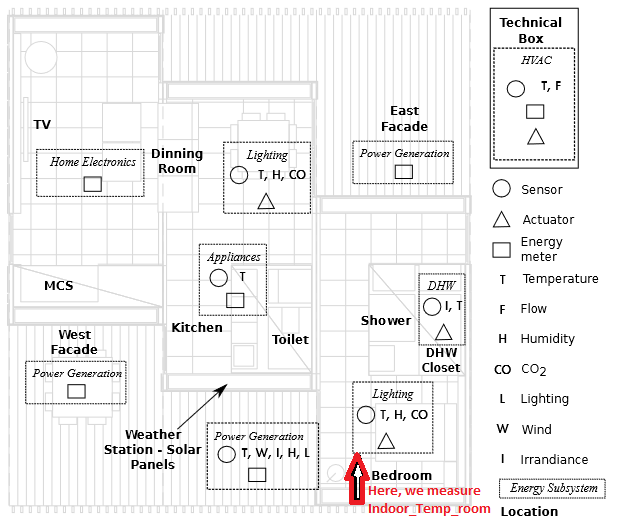


<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
    
<h1 style='background:#9AB0BD; border:0;height:50px; border-radius: 10px; color:black'><center> TABLE OF CONTENTS </center></h1>

### [**1. Importing Libraries**](#title-one)
### [**2. Data Analysis**](#title-two)
### [**3. Basic Prediction- before feature Engineering**](#title-three)
### [**4. Feature Eng and analysis**](#title-four)
### [**5. Removing some Rows**](#title-five)
### [**6. Linear Regression**](#title-six)
### [**7. XGBRegressor**](#title-seven)
### [**8. LinearBoostRegressor**](#title-eight)
### [**9. MLP**](#title-nine)
    
<a id="title-one"></a>
<h1 style='background:#9AB0BD; border:4;height:40px; border-radius: 30px; color:black'><center>Importing Libraries</center></h1>

In [4]:
import pandas as pd
import numpy as np

In [5]:
!pip install catboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 MB 10.4 MB/s eta 0:00:00


In [6]:
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from catboost import CatBoostClassifier
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

<a id="title-two"></a>
<h1 style='background:#9AB0BD; border:4;height:40px; border-radius: 30px; color:black'><center>Data Analysis</center></h1>

In [7]:
total_data.head()

,Id,Date,Time,CO2_(dinning-room),CO2_room,Relative_humidity_(dinning-room),Relative_humidity_room,Lighting_(dinning-room),Lighting_room,Meteo_Rain,Meteo_Sun_dusk,Meteo_Wind,Meteo_Sun_light_in_west_facade,Meteo_Sun_light_in_east_facade,Meteo_Sun_light_in_south_facade,Meteo_Sun_irradiance,Outdoor_relative_humidity_Sensor,Day_of_the_week
0,0,13/03/2012,11:45,216.560,221.920,39.9125,42.4150,81.6650,113.520,0.0,623.360,1.42625,9690.24,12604.20,95436.8,758.880,48.3750,2.0
1,1,13/03/2012,12:00,219.947,220.363,39.9267,42.2453,81.7413,113.605,0.0,623.211,1.59200,11022.00,10787.20,95436.8,762.069,47.8080,2.0
2,2,13/03/2012,12:15,219.403,218.933,39.7720,42.2267,81.4240,113.600,0.0,622.656,1.89133,13960.50,9669.63,95398.6,766.251,47.4320,2.0
3,3,13/03/2012,12:30,218.613,217.045,39.7760,42.0987,81.5013,113.344,0.0,622.571,1.82800,18511.20,9648.13,95360.3,766.037,47.0240,2.0
4,4,13/03/2012,12:45,217.714,216.080,39.7757,42.0686,81.4657,113.034,0.0,622.400,2.36071,26349.00,9208.32,95354.9,762.743,45.4743,2.0


Observations:

> Time variable- values are noted for every 15minutes(can be changed into range of values).

> From observed 5 values, the Indoor_temperature_room increases with time(without zig-zag pattern).

> Time components are Date, Time, Day_of_the_week.

In [8]:
total_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4137 entries, 0 to 4136
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Id                                4137 non-null   int64  
 1   Date                              4137 non-null   object 
 2   Time                              4137 non-null   object 
 3   CO2_(dinning-room)                4137 non-null   float64
 4   CO2_room                          4137 non-null   float64
 5   Relative_humidity_(dinning-room)  4137 non-null   float64
 6   Relative_humidity_room            4137 non-null   float64
 7   Lighting_(dinning-room)           4137 non-null   float64
 8   Lighting_room                     4137 non-null   float64
 9   Meteo_Rain                        4137 non-null   float64
 10  Meteo_Sun_dusk                    4137 non-null   float64
 11  Meteo_Wind                        4137 non-null   float64
 12  Meteo_

The code calculates and displays descriptive statistics (mean, standard deviation, min, max, quartiles, etc.) for each numerical column in the 'total_data' dataset.






In [9]:
total_data.describe()

,Id,CO2_(dinning-room),CO2_room,Relative_humidity_(dinning-room),Relative_humidity_room,Lighting_(dinning-room),Lighting_room,Meteo_Rain,Meteo_Sun_dusk,Meteo_Wind,Meteo_Sun_light_in_west_facade,Meteo_Sun_light_in_east_facade,Meteo_Sun_light_in_south_facade,Meteo_Sun_irradiance,Outdoor_relative_humidity_Sensor,Day_of_the_week
count,4137.000000,4137.000000,4137.000000,4137.000000,4137.000000,4137.000000,4137.000000,4137.000000,4137.000000,4137.000000,4137.000000,4137.000000,4137.000000,4137.000000,4137.000000,4137.000000
mean,2068.000000,206.599835,209.611623,42.389879,44.546069,28.970248,42.335496,0.038756,335.094312,1.304623,14749.149509,13566.284958,19857.184071,232.203649,53.251632,3.962549
std,1194.393361,22.763114,24.183477,7.215405,8.297436,25.684356,42.602571,0.187128,304.513038,1.223829,25306.450482,23311.852941,29494.598354,312.460713,13.511063,1.988923
min,0.000000,187.339000,188.907000,26.173300,27.256000,10.740000,11.328000,0.000000,0.606667,0.000000,0.000000,0.000000,0.000000,-4.164670,22.246700,1.000000
25%,1034.000000,200.228000,201.707000,36.088000,38.446700,11.540700,13.509300,0.000000,0.650000,0.168667,0.000000,0.000000,0.000000,-3.250670,42.650700,2.000000
50%,2068.000000,205.131000,208.907000,42.776000,44.802700,14.126700,22.085300,0.000000,612.821000,0.962667,752.640000,1025.020000,645.120000,11.246000,54.717300,4.000000
75%,3102.000000,210.016000,212.331000,47.584000,50.301300,40.034700,55.064000,0.000000,619.712000,2.225330,14627.500000,12907.200000,33263.600000,479.552000,63.128000,6.000000
max,4136.000000,594.389000,609.237000,60.957300,62.594700,111.797000,162.965000,1.000000,625.003000,6.321330,95278.400000,92367.500000,95704.400000,1094.660000,83.805300,7.000000


The code checks for the presence of missing (NaN) values in the 'total_data' dataset and returns the count of missing values for each column. It confirms that there are no missing values in the dataset.






In [10]:
#No nan values in the dataset.
total_data.isnull().sum()

Id                                  0
Date                                0
Time                                0
CO2_(dinning-room)                  0
CO2_room                            0
Relative_humidity_(dinning-room)    0
Relative_humidity_room              0
Lighting_(dinning-room)             0
Lighting_room                       0
Meteo_Rain                          0
Meteo_Sun_dusk                      0
Meteo_Wind                          0
Meteo_Sun_light_in_west_facade      0
Meteo_Sun_light_in_east_facade      0
Meteo_Sun_light_in_south_facade     0
Meteo_Sun_irradiance                0
Outdoor_relative_humidity_Sensor    0
Day_of_the_week                     0
dtype: int64

The code creates a correlation heatmap using Seaborn library to visualize the correlation between the numerical columns in the 'total_data' dataframe. The heatmap shows the strength and direction of the linear relationships between the variables, with annotated correlation values.






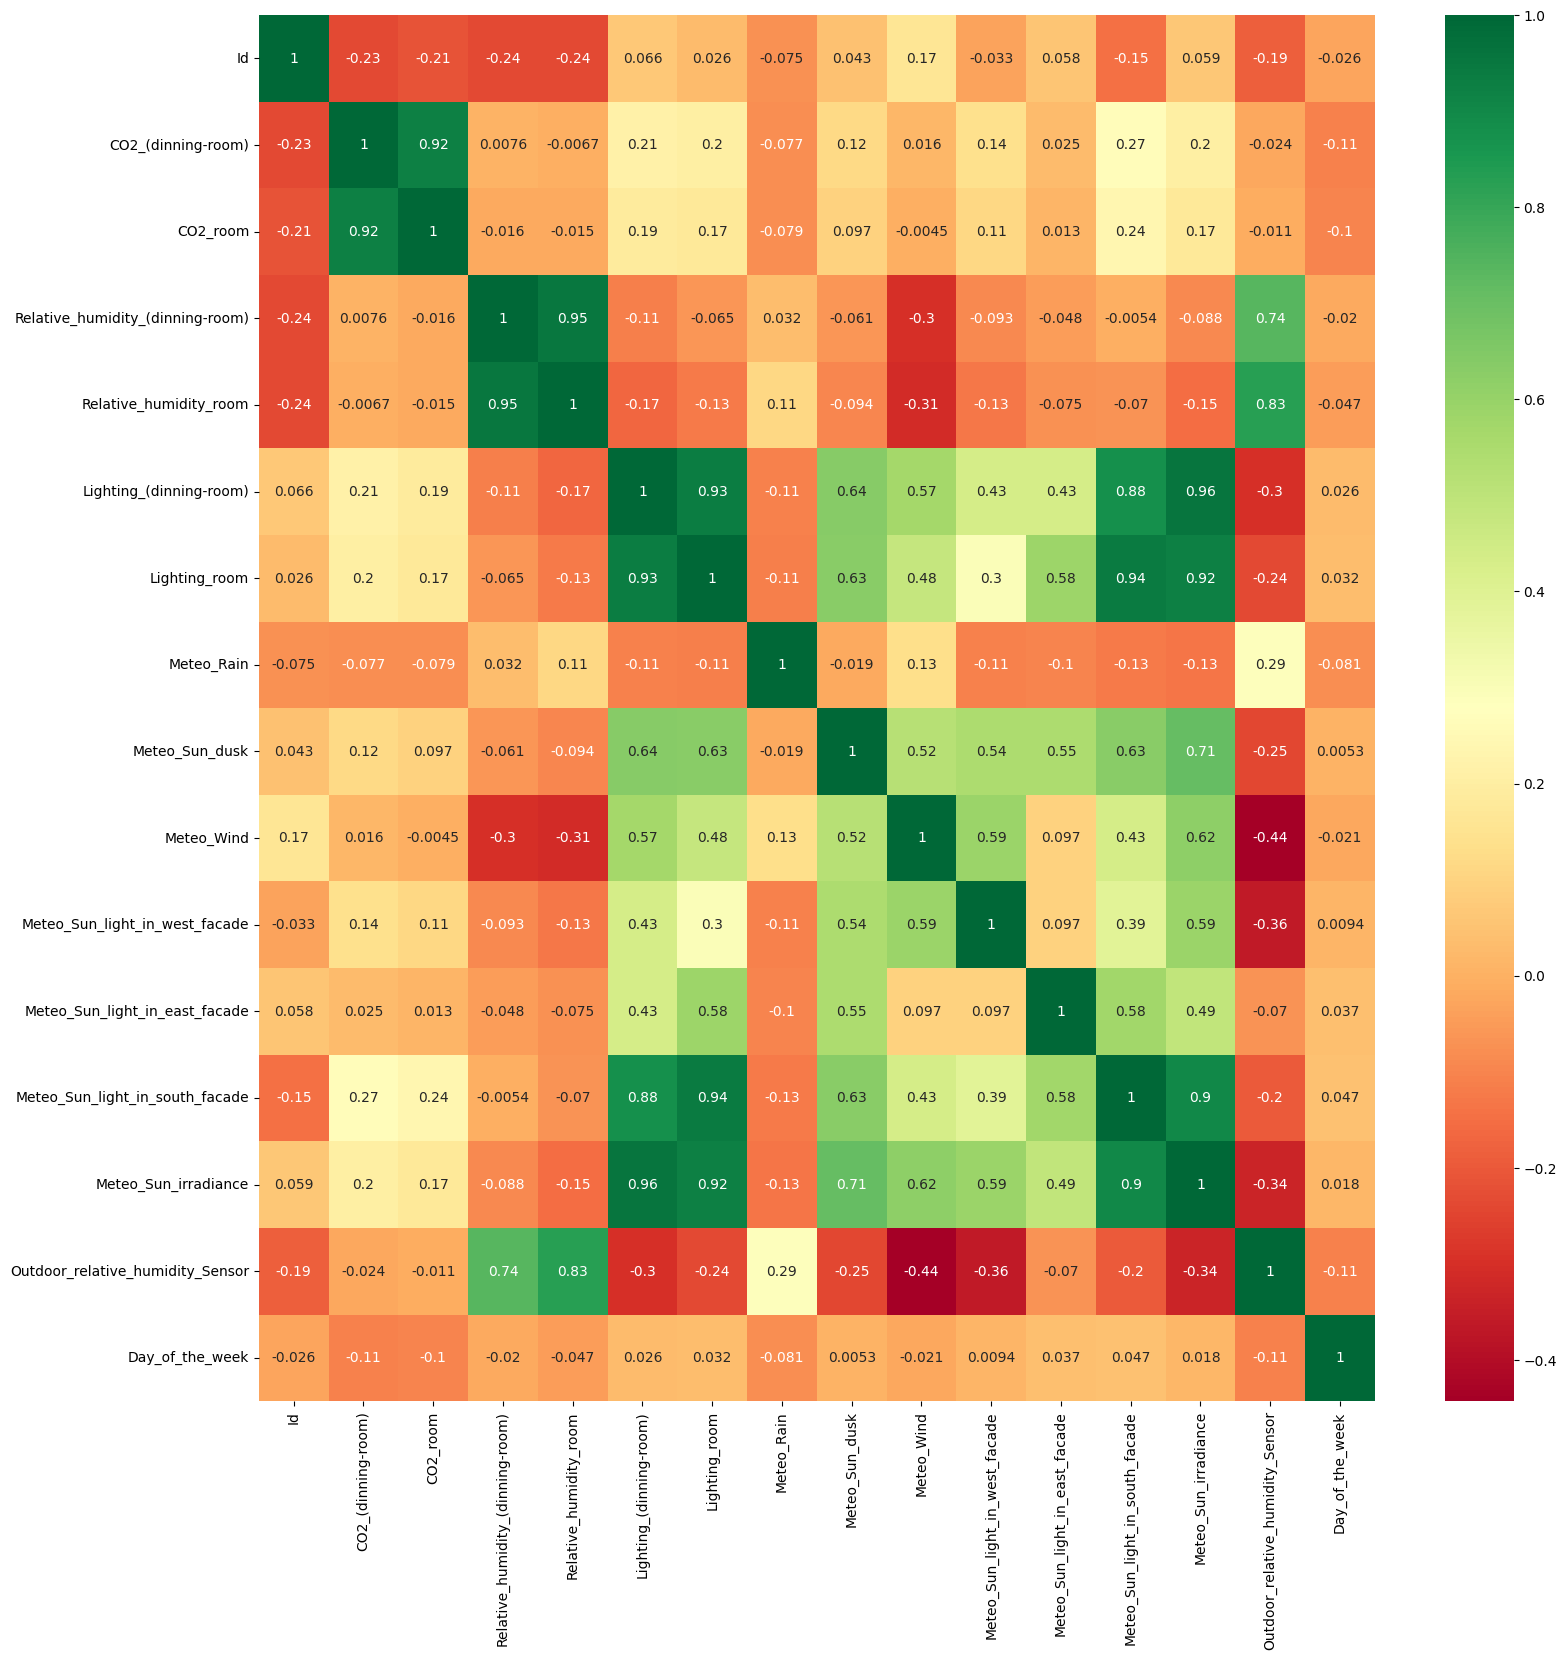

In [11]:
plt.figure(figsize = (18,18))
sns.heatmap(total_data.corr(), annot = True, cmap = "RdYlGn")
plt.show()

> Some of the variables are highly correlated with each other(Ex:-CO2_(dinning-room),CO2_room), which leads to multicollinearity.

1. Remove some of the highly correlated independent variables.
2. Linearly combine the independent variables, such as adding them together.
3. Perform an analysis designed for highly correlated variables, such as principal components analysis or partial least squares regression.
4. LASSO and Ridge regression are advanced forms of regression analysis that can handle multicollinearity. If you know how to perform linear least squares regression, you’ll be able to handle these analyses with just a little additional study.

In [12]:
train.columns

Index(['Id', 'Date', 'Time', 'CO2_(dinning-room)', 'CO2_room',
       'Relative_humidity_(dinning-room)', 'Relative_humidity_room',
       'Lighting_(dinning-room)', 'Lighting_room', 'Meteo_Rain',
       'Meteo_Sun_dusk', 'Meteo_Wind', 'Meteo_Sun_light_in_west_facade',
       'Meteo_Sun_light_in_east_facade', 'Meteo_Sun_light_in_south_facade',
       'Meteo_Sun_irradiance', 'Outdoor_relative_humidity_Sensor',
       'Day_of_the_week', 'Indoor_temperature_room'],
      dtype='object')

From the Graph

> Output has high correlation between variables Relavtive_humidity_room,Meteo_Sun_light_in_west_facade, Outdoor_relative_humidity_Sensor.

> Least correlation with Lighting_room,Meteo_Sun_light_in_south_facade

The code creates histograms for each numerical column in the 'train' dataframe using Matplotlib. It sets the number of bins to 10 and adjusts the layout to fit the histograms neatly within the plot.






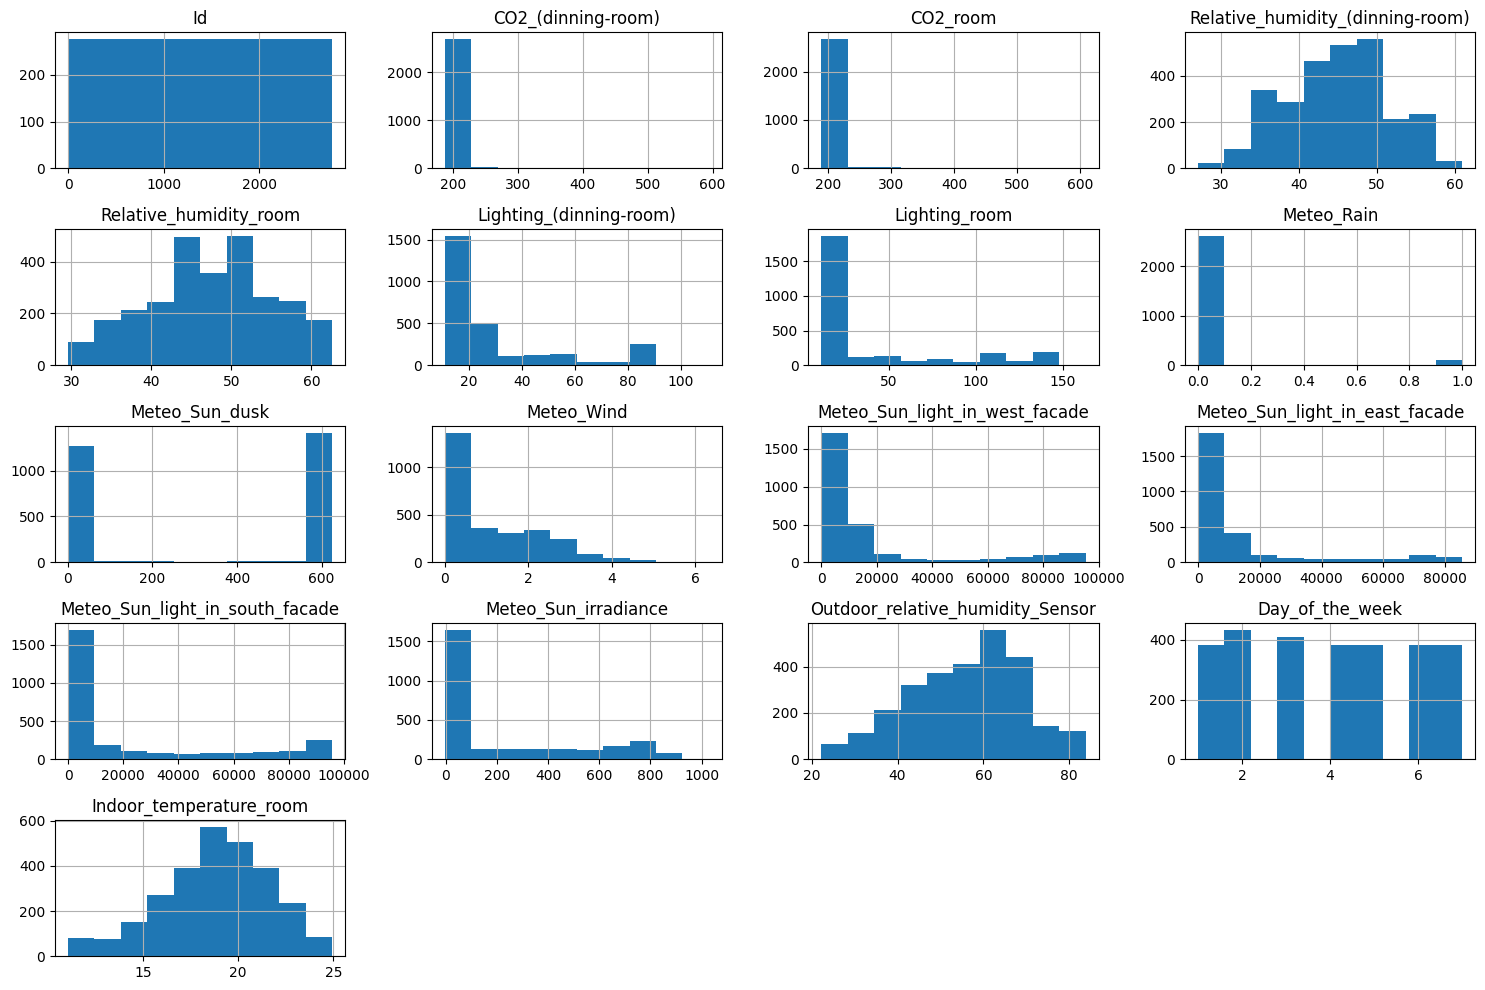

In [14]:
train.hist(bins=10, figsize=(15, 10))
plt.tight_layout()

>  Relative_humidity_(dinning room) and Outdoor_relative_humidity_Sensor are left skewed(so can apply log function)

<a id="title-three"></a>
<h1 style='background:#9AB0BD; border:4;height:40px; border-radius: 30px; color:black'><center>Basic Prediction- before feature Engineering
</center></h1>

The code separates the input features 'X' and target variable 'Y' from the 'train' dataframe. Then, it splits the data into training and validation sets (x_train, x_val, y_train, y_val) using a test size of 20% and a random seed of 40 for reproducibility.






In [15]:
X=train.drop(['Indoor_temperature_room','Id','Date','Time'],axis=1)
Y=train['Indoor_temperature_room']
x_train, x_val, y_train, y_val = train_test_split(X, Y, test_size=0.2, random_state=40)

The code creates a linear regression model 'lnr' and fits it to the training data (x_train, y_train). It then makes predictions on the training data and calculates the mean squared error (MSE) between the predicted values and the actual target values to evaluate the model's accuracy.




